### Miguel Baños Baladrón
### Miguel Pérez Francos
### Rodrigo Touceda Tapias


# Proyecto de investigación: Reconocimiento de Actividades Humanas (HAR)con Sensores Inerciales

# Importaciones

In [21]:
include("setup.jl")
include("helpers.jl")
include("wrappers.jl")

# Usamos JLD2 para recuperar el estado exacto del preprocesamiento.
if isfile("datos_procesados.jld2")
    JLD2.@load "datos_procesados.jld2" df_trainval df_test X_trainval y_trainval folds_trainval
    println("Datos cargados correctamente.")
    println("   - Registros de entrenamiento: $(nrow(df_trainval))")
    println("   - Estructura de folds recuperada: $(typeof(folds_trainval))")
else
    error("No se encontró 'datos_procesados.jld2'. Ejecuta primero Preprocess.ipynb.")
end

Entorno cargado correctamente. Constantes: SEED=104, N_FEATURES=561
Entorno cargado correctamente. Constantes: SEED=104, N_FEATURES=561
Datos cargados correctamente.
   - Registros de entrenamiento: 9205
   - Estructura de folds recuperada: Vector{Tuple{Vector{Int64}, Vector{Int64}}}


# Función para ejecutar modelos

### Esta función tiene como objetivo sistematizar la evaluación de combinaciones entre técnias de selección de características, reducción de dimensionalidad y clasificadores:
- ### Para que cada técnica aparezca al menos una vez, calculamos el número máximo de iteraciones (usando la lista de los modelos, la más larga) y se asignan filtros y reducciones de forma cíclica.
- ### Es reproducible, ya que convierte los diccionarios en listas ordenadas alfabéticamente.
- ### Añadimos una lógica de checkpoint, para que en caso de que la ejecución se detenga antes de terminar, la reanude desde el error, en vez de volver a empezar. Guardamos las métricas en un CSV.
- ### Extraemos accuracy, f1_score, balanced_accuracy media y por cada fold.

In [22]:
function run_models(dic_filtros, dic_reducciones, dic_modelos, output_file; 
                    X=X_trainval, y=y_trainval, folds=folds_trainval)
    
    # Convierte diccionarios a listas ordenadas para ejecución determinista
    list_filtros     = sort(collect(dic_filtros), by=x->x[1])
    list_reducciones = sort(collect(dic_reducciones), by=x->x[1])
    list_modelos     = sort(collect(dic_modelos), by=x->x[1])

    # Calcula longitud de cada lista de opciones
    n_filtros = length(list_filtros)
    n_reducciones = length(list_reducciones)
    n_modelos = length(list_modelos)

    # Define el número máximo de iteraciones para cubrir todas las técnicas
    max_iter = max(n_filtros, n_reducciones, n_modelos)
    
    # Comprueba si existe archivo previo para reanudar o iniciar de cero
    if isfile(output_file)
        results_df = CSV.read(output_file, DataFrame)
        # Crea conjunto de identificadores para evitar repetir experimentos
        combinaciones_hechas = Set([
            (string(r.Filter), string(r.Reduction), string(r.Model)) 
            for r in eachrow(results_df)
        ])
    else
        # Inicializa DataFrame vacío con las columnas de métricas
        results_df = DataFrame(
            Filter = String[], Reduction = String[], Model = String[],
            Accuracy_Mean = Float64[], 
            F1_Score = Float64[], 
            B_Accuracy_mean = Float64[],
            B_accuracy_list = String[]
        )
        combinaciones_hechas = Set{Tuple{String, String, String}}()
    end
    
    # Define métricas: Accuracy, F1 y Balanced Accuracy
    measures = [accuracy, multiclass_f1score, balanced_accuracy]

    println("Iniciando ejecución: $max_iter experimentos totales.")

    # Bucle principal iterando cíclicamente
    for i in 1:max_iter
        # Selección modular de componentes para cubrir todas las opciones
        pair_filt = list_filtros[(i - 1) % n_filtros + 1]
        pair_red  = list_reducciones[(i - 1) % n_reducciones + 1]
        pair_mod  = list_modelos[(i - 1) % n_modelos + 1]

        # Desempaqueta nombres y objetos
        filt_name, filt_model = pair_filt
        red_name, red_model   = pair_red
        mod_name, mod_model   = pair_mod

        # Salta iteración si la combinación ya existe
        if (filt_name, red_name, mod_name) in combinaciones_hechas
            continue 
        end

        println("\nEvaluando ($i/$max_iter): [$filt_name] + [$red_name] + [$mod_name]")
        
        # Construye el pipeline con las técnicas seleccionadas
        pipe = PersonalizedPipeline(
            scaler    = MyMinMaxScaler(), 
            filter    = filt_model,      
            reduction = red_model,       
            clf       = mod_model        
        )
        
        try
            # Instancia la 'machine' de MLJ y ejecuta evaluación
            mach = machine(pipe, X, y) 
            evaluation = evaluate!(
                mach, 
                resampling = folds, 
                measures = measures, 
                verbosity = 0,
                acceleration = CPUThreads() 
            )
            
            # Extrae medias de las métricas
            acc_mean = evaluation.measurement[1]
            f1_mean   = evaluation.measurement[2]
            b_acc_mean   = evaluation.measurement[3]
            
            # Obtiene lista de Balanced Accuracy por fold y serializa a string
            b_acc_folds = evaluation.per_fold[3]
            b_acc_str = join(round.(b_acc_folds, digits=5), ";")

            println("Acc: $(round(acc_mean, digits=4)) | F1: $(round(f1_mean, digits=4)) | B_acc: $(round(b_acc_mean, digits=4))")
            
            # Guarda resultados en DataFrame y actualiza CSV
            push!(results_df, (filt_name, red_name, mod_name, acc_mean, f1_mean, b_acc_mean, b_acc_str), promote=true)
            CSV.write(output_file, results_df)
            
        catch e
            # Captura errores para no detener el flujo y registra fallo
            println("ERROR en $filt_name + $red_name + $mod_name: $e")
            push!(results_df, (filt_name, red_name, mod_name, NaN, NaN, NaN, "ERROR"))
            CSV.write(output_file, results_df)
        end
        
        # Libera memoria tras cada iteración
        GC.gc()
    end
    
    println("Experimento finalizado.")
    return results_df
end

run_models (generic function with 1 method)

# Definición de los diccionarios para los modelos básicos y selección de atributos

In [23]:
# Diccionarios de los filtrados
dic_filtros = Dict(
    "Sin_Filtrado" => nothing,
    "ANOVA" => MyANOVAFilter(n_features=N_FEATURES),
    "Pearson" => MyPearsonFilter(n_features=N_FEATURES),
    "Spearman" => MySpearmanFilter(n_features=N_FEATURES),
    "Kendall" => MyKendallFilter(n_features=N_FEATURES),
    "MI" => MyMIFilter(n_features=N_FEATURES),
    "RFE" => MyRFEFilter(n_features=N_FEATURES)
)

# Diccionarios de las reducciones de dimensionalidad
dic_reducciones = Dict(
    "Sin reducción" => IdentityTransformer(),
    "PCA" => PCA(variance_ratio=0.95), # Conservar el 95% de la varianza
    "ICA" => ICA(outdim=2, maxiter=10000,tol=0.5), # Tolerancia alta para evitar error
    "LDA" => LDA(method=:whiten, outdim=5) # En LDA, la dimensión es n_classes - 1
)

# Diccionarios de modelos
dic_modelos = Dict(
    # MLP
    "NeuralNetwork_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
    "NeuralNetwork_100" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100,))),
    "NeuralNetwork_100_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50))),
    
    # KNN
    "KNN_1" => KNNClassifier(K=1),
    "KNN_10" => KNNClassifier(K=10),
    "KNN_20" => KNNClassifier(K=20),

    # SVM
    "SVM_0.1" => ProbabilisticSVC(cost=0.1),
    "SVM_0.5" => ProbabilisticSVC(cost=0.5),
    "SVM_1.0" => ProbabilisticSVC(cost=1.0)
);

In [24]:
# Ejecutar y guardar
df_resultados_basicos = run_models(
    dic_filtros, 
    dic_reducciones, 
    dic_modelos, 
    "resultados_modelos_basicos.csv"
)

Iniciando ejecución: 9 experimentos totales.
Experimento finalizado.


Row,Filter,Reduction,Model,Accuracy_Mean,F1_Score,B_Accuracy_mean,B_accuracy_list
,String15,String15,String31,Float64,Float64,Float64,String
1,ANOVA,ICA,KNN_1,0.591744,0.590583,0.590066,0.62677;0.55199;0.61759;0.57407;0.5792
2,Kendall,LDA,KNN_10,0.957523,0.957549,0.957705,0.96633;0.94923;0.95082;0.94778;0.97424
3,MI,PCA,KNN_20,0.894079,0.893302,0.893082,0.89989;0.87871;0.89793;0.91762;0.87073
4,Pearson,Sin reducción,NeuralNetwork_100,0.893753,0.890863,0.892993,0.9291;0.84141;0.88771;0.86468;0.94273
5,RFE,ICA,NeuralNetwork_100_50,0.586312,0.550403,0.584556,0.58401;0.56956;0.5786;0.53971;0.65389
6,Sin_Filtrado,LDA,NeuralNetwork_50,0.889517,0.885942,0.893031,0.89364;0.91274;0.90341;0.91095;0.84206
7,Spearman,PCA,SVM_0.1,0.910483,0.909962,0.910647,0.9292;0.89265;0.92234;0.9105;0.89776
8,ANOVA,Sin reducción,SVM_0.5,0.933732,0.933374,0.933782,0.9595;0.91366;0.93447;0.92812;0.93167
9,Kendall,ICA,SVM_1.0,0.670831,0.66181,0.669607,0.67827;0.67086;0.69487;0.66097;0.64239


# Definición de los diccionarios de los modelos de ensemble (Primer Experimento)

### Para la parte de ensembles, reciclamos la función run_models y usamos la misma idea, definir diccionarios de filtrados (tenemos que indicar que no hay), reducciones (solo PCA 95% o sin) y modelos. El apartado de modelos esta vez se ha centrado en pruebas de Bagging y Boosting.
### En el caso de AdaBoost, usamos AdaBoostStumpClassifier que a diferencia de usar SVM como base, usa Decission Stumps (Decission Trees de profundidad 1). Como son aprendices débiles, ejecutamos varios modelos para encontrar un número de iteraciones óptimo. Hasta las 300 iteraciones obtuvimos mejoría, pero en las 400, empeoraron las métricas, mostrando overfitting.

In [25]:
# No se especifica usar ningún filtrado para ensembles, debemos decirle a nuestra función que no hay
dic_filtros_ensemble = Dict(
    "Sin_Filtrado" => nothing
)

# Usamos PCA con el 95% de la varianza o ninguno
dic_reducciones_ensemble = Dict(
    "Sin_Reduccion" => IdentityTransformer(), 
    "PCA_95"        => PCA(variance_ratio=0.95)
)

# Definición del knn base para Bagging
knn_base = KNNClassifier(K=5)

# Diccionario de los modelos de ensemble
dic_modelos_ensemble = Dict(
    # BaggingClassifier
    "Bagging_KNN_10" => EnsembleModel(model = knn_base, n = 10),
    "Bagging_KNN_50" => EnsembleModel(model = knn_base, n = 50),

    # AdaBoost
    "AdaBoost" => AdaBoostStumpClassifier(n_iter = 100),
    "AdaBoost200" => AdaBoostStumpClassifier(n_iter = 200),
    "AdaBoost300" => AdaBoostStumpClassifier(n_iter = 300),
    "AdaBoost400" => AdaBoostStumpClassifier(n_iter = 400),

    # EvoTree
    "EvoTree_50" => EvoTreeClassifier(nrounds = 50, eta = 0.2),
    "EvoTree_100" => EvoTreeClassifier(nrounds = 100, eta = 0.2)
);

In [26]:
df_resultados_ensembles = run_models(
    dic_filtros_ensemble, 
    dic_reducciones_ensemble, 
    dic_modelos_ensemble, 
    "resultados_modelos_ensemble.csv"
)

Iniciando ejecución: 8 experimentos totales.
Experimento finalizado.


Row,Filter,Reduction,Model,Accuracy_Mean,F1_Score,B_Accuracy_mean,B_accuracy_list
,String15,String15,String15,Float64,Float64,Float64,String
1,Sin_Filtrado,PCA_95,AdaBoost,0.678979,0.660709,0.680322,0.69891;0.66974;0.65539;0.73831;0.6353
2,Sin_Filtrado,Sin_Reduccion,AdaBoost200,0.691363,0.629179,0.688138,0.71354;0.73806;0.74363;0.58393;0.6582
3,Sin_Filtrado,PCA_95,AdaBoost300,0.717545,0.708043,0.718855,0.69365;0.73162;0.72019;0.77213;0.67699
4,Sin_Filtrado,Sin_Reduccion,AdaBoost400,0.694622,0.646512,0.698293,0.68917;0.75569;0.77697;0.57058;0.7008
5,Sin_Filtrado,PCA_95,Bagging_KNN_10,0.891146,0.889547,0.889873,0.89135;0.89049;0.8842;0.9118;0.8704
6,Sin_Filtrado,Sin_Reduccion,Bagging_KNN_50,0.897773,0.896354,0.896264,0.903;0.88809;0.89366;0.92148;0.87395
7,Sin_Filtrado,PCA_95,EvoTree_100,0.881477,0.877813,0.878653,0.90069;0.87467;0.89897;0.88948;0.82665
8,Sin_Filtrado,Sin_Reduccion,EvoTree_50,0.918197,0.916742,0.917156,0.94231;0.88292;0.91685;0.91872;0.92454


# Evaluación final sobre el conjunto de test

In [27]:
# Unificamos diccionarios
all_filtros     = merge(dic_filtros, dic_filtros_ensemble)
all_reducciones = merge(dic_reducciones, dic_reducciones_ensemble)
all_modelos     = merge(dic_modelos, dic_modelos_ensemble);

In [29]:
# Mejor KNN
best_knn = get_better("KNN", "resultados_modelos_basicos.csv")

# Mejor SVM
best_svm = get_better("SVM", "resultados_modelos_basicos.csv")

# Mejor MLP 
best_mlp = get_better("NeuralNetwork", "resultados_modelos_basicos.csv")

# Mejor Bagging 
best_bagging = get_better("Bagging", "resultados_modelos_ensemble.csv")

# Mejor AdaBoost
best_adaboost = get_better("AdaBoost", "resultados_modelos_ensemble.csv")

# Mejor EvoTree
best_evotree = get_better("EvoTree", "resultados_modelos_ensemble.csv");

Mejor KNN encontrado:
Config: Kendall + LDA + KNN_10
-> B_Accuracy_mean: 0.9577

Mejor SVM encontrado:
Config: ANOVA + Sin reducción + SVM_0.5
-> B_Accuracy_mean: 0.9338

Mejor NeuralNetwork encontrado:
Config: Sin_Filtrado + LDA + NeuralNetwork_50
-> B_Accuracy_mean: 0.893

Mejor Bagging encontrado:
Config: Sin_Filtrado + Sin_Reduccion + Bagging_KNN_50
-> B_Accuracy_mean: 0.8963

Mejor AdaBoost encontrado:
Config: Sin_Filtrado + PCA_95 + AdaBoost300
-> B_Accuracy_mean: 0.7189

Mejor EvoTree encontrado:
Config: Sin_Filtrado + Sin_Reduccion + EvoTree_50
-> B_Accuracy_mean: 0.9172



In [35]:
# Separamos X e y del conjunto de test 
y_test = df_test.Activity
X_test = DataFrames.select(df_test, Not([:subject, :Activity]));

In [36]:
# Agrupamos los mejores modelos encontrados en un diccionario
mejores_modelos = Dict(
    "SVM (Best)" => best_svm,
    "KNN (Best)" => best_knn,
    "MLP (Best)" => best_mlp,
    "Bagging (Best)" => best_bagging,
    "AdaBoost (Best)" => best_adaboost,
    "EvoTree (Best)" => best_evotree
)

# Diccionario para acumular las matrices de confusión y pasarlas a show_cm()
dic_matrices_test = Dict()
output_file_test = "resultados_finales_test.csv" # Archivo csv para guardar las métricas
resultados_test = DataFrame(Modelo=String[], Accuracy=Float64[], F1_Score=Float64[], B_Accuracy=Float64[]) # DataFrame para guardar métricas

println("=== Iniciando Evaluación Final en TEST ===")

for (nombre, pipeline) in mejores_modelos
    println("Procesando: $nombre ...")
    
    # Creamos la machine usando todo el conjunto de entrenamiento (Entrenamiento + Validación)
    mach = machine(pipeline, X_trainval, y_trainval)
    
    # Entrenamos
    fit!(mach, verbosity=0)
    
    # Evaluamos con test
    y_pred = predict_mode(mach, X_test)
    
    # Calculamos métricas
    acc = accuracy(y_pred, y_test)
    f1  = multiclass_f1score(y_pred, y_test)
    b_acc = balanced_accuracy(y_pred, y_test)
    
    push!(resultados_test, (nombre, acc, f1, b_acc))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_pred, y_test)
    dic_matrices_test[nombre] = cm
end

# Guardar en el csv
CSV.write(output_file_test, resultados_test)
println("Resultados de test guardados en: $output_file_test")

# Mostrar tabla resumen
println("\nResultados Finales en Test:")
pretty_table(resultados_test)

=== Iniciando Evaluación Final en TEST ===
Procesando: SVM (Best) ...
Procesando: AdaBoost (Best) ...
Procesando: EvoTree (Best) ...
Procesando: KNN (Best) ...
Procesando: MLP (Best) ...
Procesando: Bagging (Best) ...
Resultados de test guardados en: resultados_finales_test.csv

Resultados Finales en Test:
┌─────────────────┬──────────┬──────────┬────────────┐
│          Modelo │ Accuracy │ F1_Score │ B_Accuracy │
│          String │  Float64 │  Float64 │    Float64 │
├─────────────────┼──────────┼──────────┼────────────┤
│      SVM (Best) │ 0.902194 │ 0.878588 │   0.885348 │
│ AdaBoost (Best) │ 0.738574 │ 0.706983 │   0.720158 │
│  EvoTree (Best) │ 0.865631 │ 0.843422 │   0.850692 │
│      KNN (Best) │ 0.956124 │ 0.950527 │   0.949871 │
│      MLP (Best) │ 0.936015 │ 0.929095 │   0.928365 │
│  Bagging (Best) │ 0.872029 │ 0.845563 │   0.855933 │
└─────────────────┴──────────┴──────────┴────────────┘


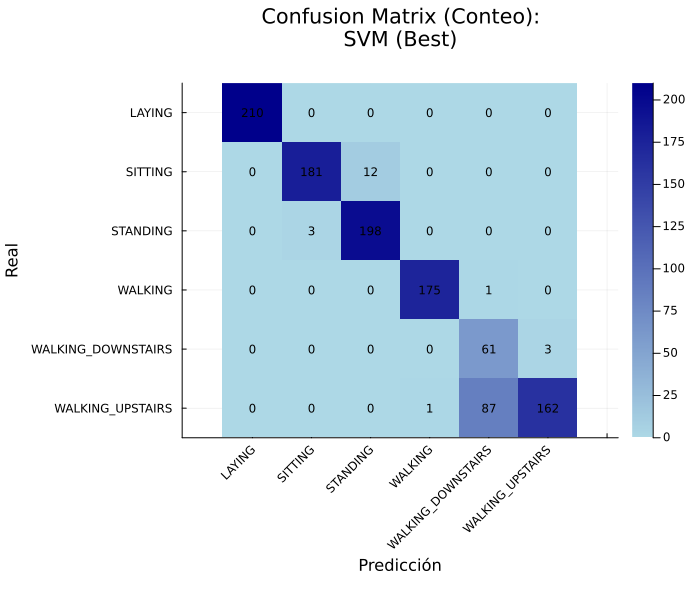

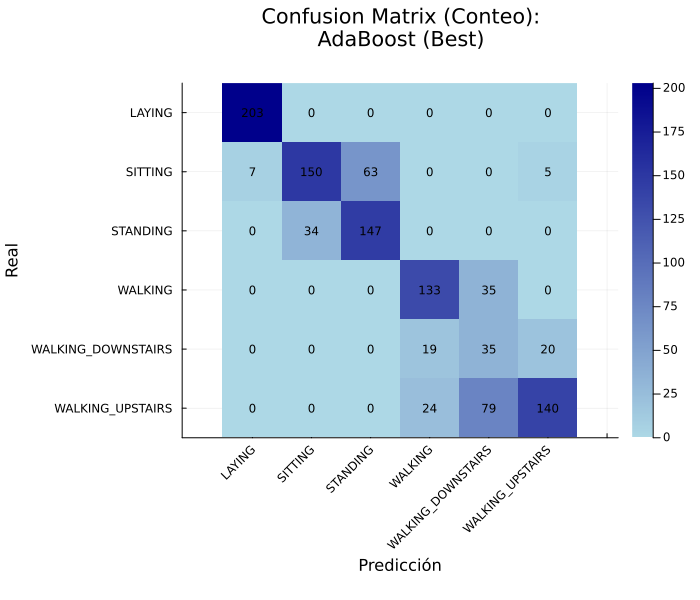

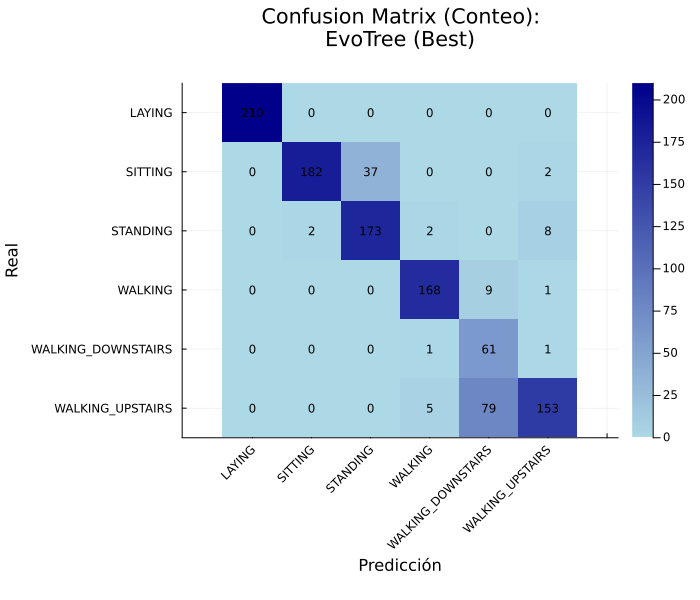

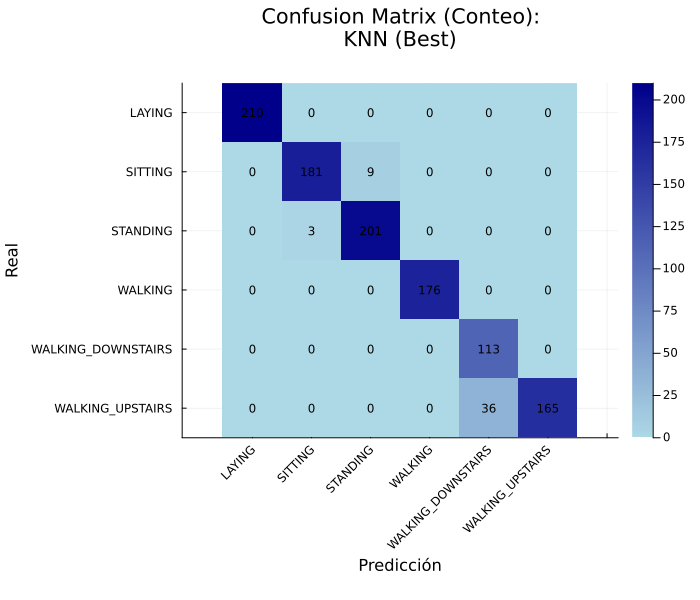

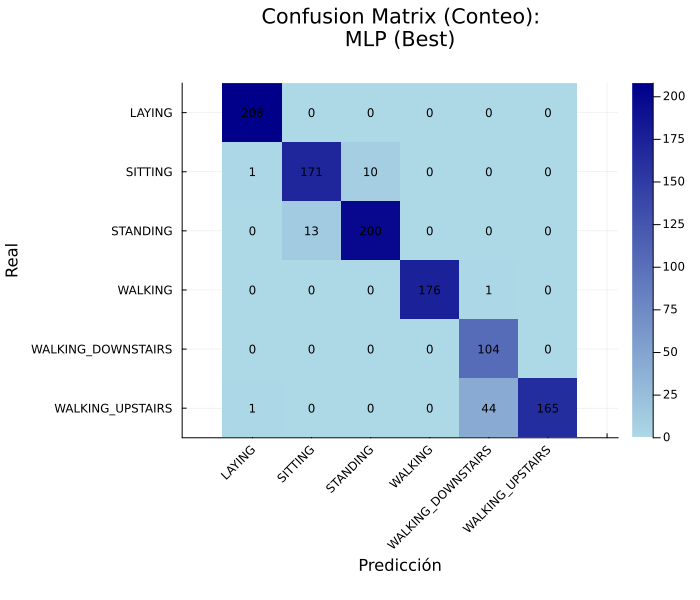

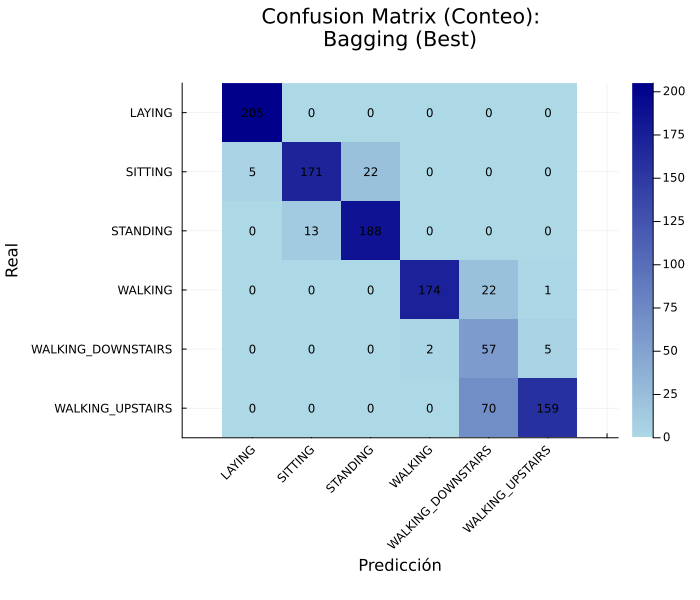

In [37]:
show_cm(dic_matrices_test)

# Modelos de ensemble (Segundo Experimento) usando entrenamiento y validación para entrenar y test para evaluar